In [123]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [124]:
from google.colab import files

uploaded = files.upload()

Saving taxi_fare_dataset_with_locations.xlsx to taxi_fare_dataset_with_locations (4).xlsx


In [125]:
import os
os.listdir()

['.config',
 'Taxi_Trips_Sample (4).csv',
 'Taxi_Trips_Sample.csv',
 'taxi_fare_dataset_with_locations (2).xlsx',
 'taxi_fare_dataset_with_locations.xlsx',
 'Taxi_Trips_Sample (5).csv',
 'taxi_fare_dataset_with_locations (4).xlsx',
 'Taxi_Trips_Sample (3).csv',
 'taxi_fare_dataset_with_locations (1).xlsx',
 'taxi_fare_dataset_with_locations (3).xlsx',
 'Taxi_Trips_Sample (1).csv',
 'Taxi_Trips_Sample (2).csv',
 'sample_data']

In [126]:
df = pd.read_excel("taxi_fare_dataset_with_locations.xlsx")

In [127]:
import pandas as pd

df = pd.read_excel("taxi_fare_dataset_with_locations.xlsx")
df.head()

,Pickup_Location,Drop_Location,Trip_Distance_km,Duration_min,Waiting_Time_min,Surge_Multiplier,Mode_of_Payment,Fare_Rs
0,Market,University,27.4,99,5,1.3,Cash,735.43
1,University,Hotel,7.8,32,7,1.1,Credit Card,249.66
2,Central Station,Hospital,7.0,23,7,1.5,Credit Card,299.83
3,Hospital,University,19.7,71,6,1.1,Cash,470.06
4,IT Park,University,4.7,24,10,1.2,Debit Card,215.17


In [128]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1K5g6WfJFUOHi8nJ3W5hfDfEIhiT2xtVG0uM2G2LKlq8/edit#gid=0


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pickup_Location   500 non-null    object 
 1   Drop_Location     500 non-null    object 
 2   Trip_Distance_km  500 non-null    float64
 3   Duration_min      500 non-null    int64  
 4   Waiting_Time_min  500 non-null    int64  
 5   Surge_Multiplier  500 non-null    float64
 6   Mode_of_Payment   500 non-null    object 
 7   Fare_Rs           500 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 31.4+ KB


In [130]:
df.isnull().sum()

,0
Pickup_Location,0
Drop_Location,0
Trip_Distance_km,0
Duration_min,0
Waiting_Time_min,0
Surge_Multiplier,0
Mode_of_Payment,0
Fare_Rs,0


In [131]:
df.describe()

,Trip_Distance_km,Duration_min,Waiting_Time_min,Surge_Multiplier,Fare_Rs
count,500.00000,500.000000,500.000000,500.000000,500.000000
mean,15.55520,55.618000,6.076000,1.214000,431.496080
std,8.22314,25.051052,3.856939,0.163638,192.898215
min,1.50000,7.000000,0.000000,1.000000,81.290000
25%,8.60000,35.000000,2.750000,1.100000,272.550000
50%,15.65000,56.000000,6.000000,1.200000,425.160000
75%,22.60000,76.000000,10.000000,1.300000,581.127500
max,29.80000,105.000000,12.000000,1.500000,909.610000


In [132]:
X = df.drop("Fare_Rs", axis=1)

y = df["Fare_Rs"]

In [133]:
print(X.head())

   Pickup_Location Drop_Location  Trip_Distance_km  Duration_min  \
0           Market    University              27.4            99   
1       University         Hotel               7.8            32   
2  Central Station      Hospital               7.0            23   
3         Hospital    University              19.7            71   
4          IT Park    University               4.7            24   

   Waiting_Time_min  Surge_Multiplier Mode_of_Payment  
0                 5               1.3            Cash  
1                 7               1.1     Credit Card  
2                 7               1.5     Credit Card  
3                 6               1.1            Cash  
4                10               1.2      Debit Card  


In [134]:
print(y.head())

0    735.43
1    249.66
2    299.83
3    470.06
4    215.17
Name: Fare_Rs, dtype: float64


In [135]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Pickup_Location",
    "Drop_Location",
    "Mode_of_Payment"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [137]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [138]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [139]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Pickup_Location',
                                                   'Drop_Location',
                                                   'Mode_of_Payment'])])),
                ('regressor', LinearRegression())])

In [140]:
print("Model trained successfully!")

Model trained successfully!


In [141]:
y_pred = model.predict(X_test)

In [142]:
prediction_df = X_test.copy()

prediction_df["Actual_Fare"] = y_test.values
prediction_df["Predicted_Fare"] = y_pred

prediction_df.head(10)

,Pickup_Location,Drop_Location,Trip_Distance_km,Duration_min,Waiting_Time_min,Surge_Multiplier,Mode_of_Payment,Actual_Fare,Predicted_Fare
361,Bus Stand,City Mall,25.0,89,10,1.0,UPI,533.03,588.301606
73,Hotel,Market,12.9,52,5,1.0,Debit Card,308.69,299.606931
374,Beach,Central Station,11.9,49,8,1.3,Cash,387.18,384.681873
155,Beach,Market,9.4,42,8,1.5,Cash,385.82,406.879965
104,IT Park,Market,18.0,67,10,1.5,Wallet,623.69,603.922014
394,Airport,Central Station,22.4,76,0,1.1,Wallet,497.85,517.850974
377,Railway Station,University,2.0,15,4,1.0,UPI,110.96,42.002823
124,Hotel,Central Station,14.2,42,5,1.3,Credit Card,421.34,433.873352
68,City Mall,Bus Stand,21.2,63,2,1.5,Debit Card,662.79,645.837577
450,City Mall,Bus Stand,9.5,36,12,1.3,Credit Card,340.03,366.128469


In [143]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=prediction_df)

https://docs.google.com/spreadsheets/d/1GExhqw4mfixe47iQrjiNRPFHNnB0w9R3VfOILDjIHOo/edit#gid=0


In [144]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [145]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("----------------------------")
print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Model Performance
----------------------------
Mean Absolute Error : 22.597220955635475
Mean Squared Error  : 878.4662374337333
Root Mean Squared Error : 29.63893111152515
R² Score : 0.9767275848326328


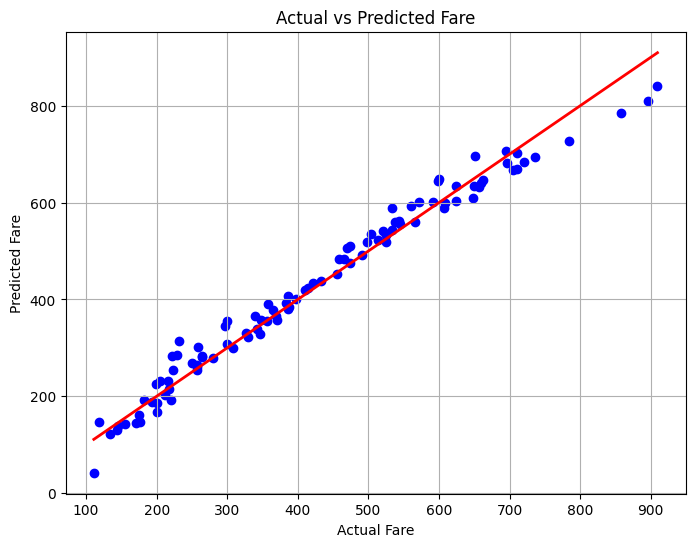

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.title("Actual vs Predicted Fare")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.grid(True)
plt.show()

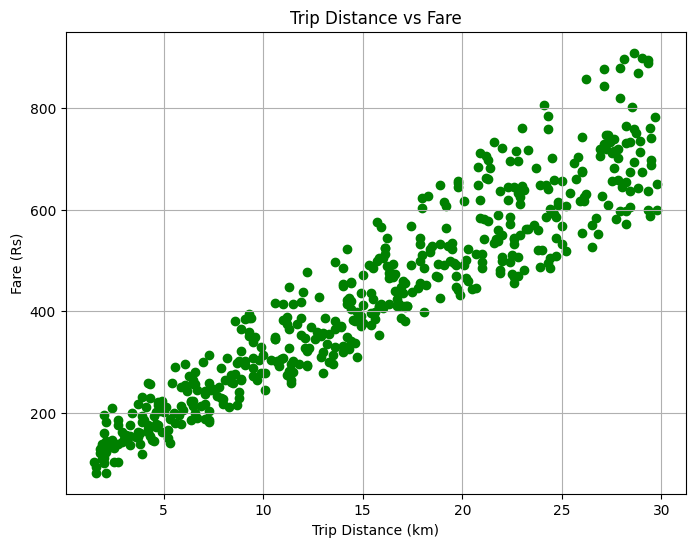

In [147]:
plt.figure(figsize=(8,6))

plt.scatter(df["Trip_Distance_km"],
            df["Fare_Rs"],
            color="green")

plt.title("Trip Distance vs Fare")
plt.xlabel("Trip Distance (km)")
plt.ylabel("Fare (Rs)")
plt.grid(True)

plt.show()

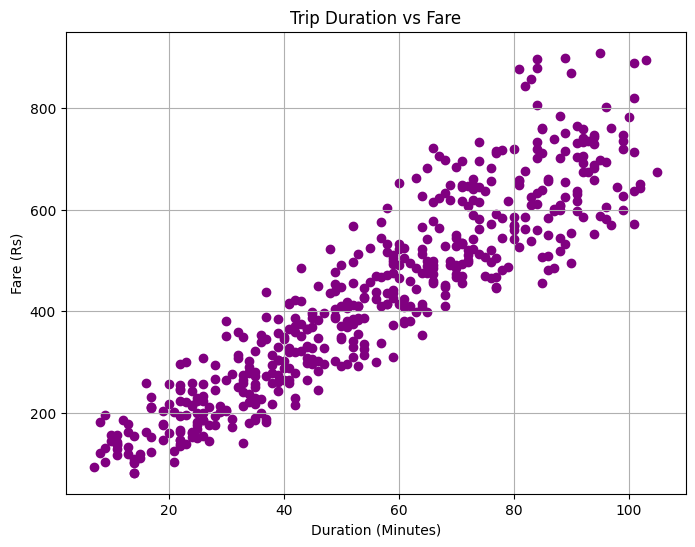

In [148]:
plt.figure(figsize=(8,6))

plt.scatter(df["Duration_min"],
            df["Fare_Rs"],
            color="purple")

plt.title("Trip Duration vs Fare")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Fare (Rs)")
plt.grid(True)

plt.show()

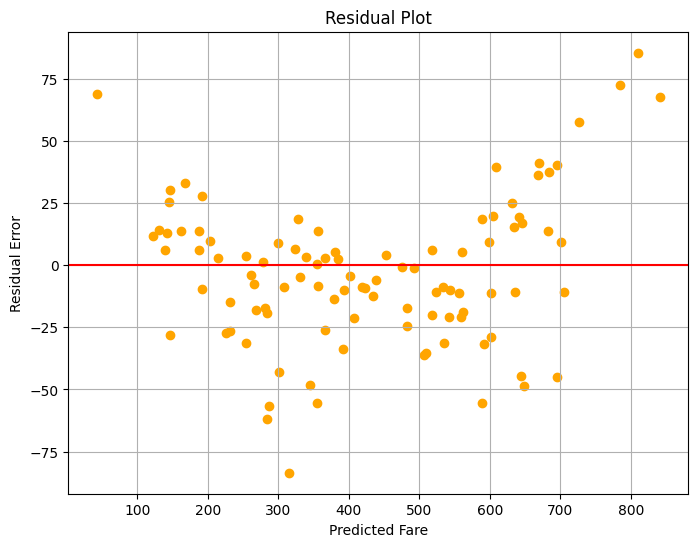

In [149]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred,
            residuals,
            color="orange")

plt.axhline(y=0, color="red")

plt.title("Residual Plot")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual Error")
plt.grid(True)

plt.show()

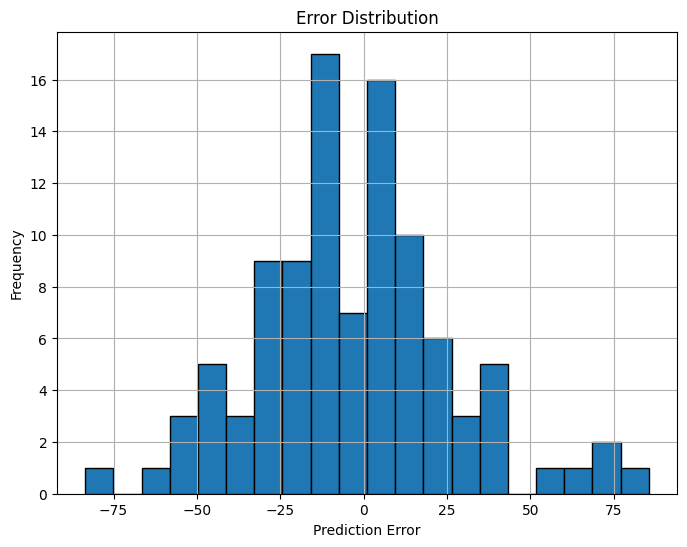

In [150]:
plt.figure(figsize=(8,6))

plt.hist(residuals,
         bins=20,
         edgecolor="black")

plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()